In [218]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,r2_score

In [219]:
df = pd.read_excel('HousePricePrediction.xlsx',engine = 'openpyxl')
df.head(10)

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0
5,5,50,RL,14115,Inside,1Fam,5,1993,1995,VinylSd,0.0,796.0,143000.0
6,6,20,RL,10084,Inside,1Fam,5,2004,2005,VinylSd,0.0,1686.0,307000.0
7,7,60,RL,10382,Corner,1Fam,6,1973,1973,HdBoard,32.0,1107.0,200000.0
8,8,50,RM,6120,Inside,1Fam,5,1931,1950,BrkFace,0.0,952.0,129900.0
9,9,190,RL,7420,Corner,2fmCon,6,1939,1950,MetalSd,0.0,991.0,118000.0


In [220]:
df.describe()

,Id,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,SalePrice
count,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2918.000000,2918.000000,1460.000000
mean,1459.000000,57.137718,10168.114080,5.564577,1971.312778,1984.264474,49.582248,1051.777587,180921.195890
std,842.787043,42.517628,7886.996359,1.113131,30.291442,20.894344,169.205611,440.766258,79442.502883
min,0.000000,20.000000,1300.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,34900.000000
25%,729.500000,20.000000,7478.000000,5.000000,1953.500000,1965.000000,0.000000,793.000000,129975.000000
50%,1459.000000,50.000000,9453.000000,5.000000,1973.000000,1993.000000,0.000000,989.500000,163000.000000
75%,2188.500000,70.000000,11570.000000,6.000000,2001.000000,2004.000000,0.000000,1302.000000,214000.000000
max,2918.000000,190.000000,215245.000000,9.000000,2010.000000,2010.000000,1526.000000,6110.000000,755000.000000


In [221]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            2919 non-null   int64  
 1   MSSubClass    2919 non-null   int64  
 2   MSZoning      2915 non-null   str    
 3   LotArea       2919 non-null   int64  
 4   LotConfig     2919 non-null   str    
 5   BldgType      2919 non-null   str    
 6   OverallCond   2919 non-null   int64  
 7   YearBuilt     2919 non-null   int64  
 8   YearRemodAdd  2919 non-null   int64  
 9   Exterior1st   2918 non-null   str    
 10  BsmtFinSF2    2918 non-null   float64
 11  TotalBsmtSF   2918 non-null   float64
 12  SalePrice     1460 non-null   float64
dtypes: float64(3), int64(6), str(4)
memory usage: 296.6 KB


In [222]:
df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           4
LotArea            0
LotConfig          0
BldgType           0
OverallCond        0
YearBuilt          0
YearRemodAdd       0
Exterior1st        1
BsmtFinSF2         1
TotalBsmtSF        1
SalePrice       1459
dtype: int64

In [223]:
df.drop_duplicates()

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,2914,160,RM,1936,Inside,Twnhs,7,1970,1970,CemntBd,0.0,546.0,NaN
2915,2915,160,RM,1894,Inside,TwnhsE,5,1970,1970,CemntBd,0.0,546.0,NaN
2916,2916,20,RL,20000,Inside,1Fam,7,1960,1996,VinylSd,0.0,1224.0,NaN
2917,2917,85,RL,10441,Inside,1Fam,5,1992,1992,HdBoard,0.0,912.0,NaN


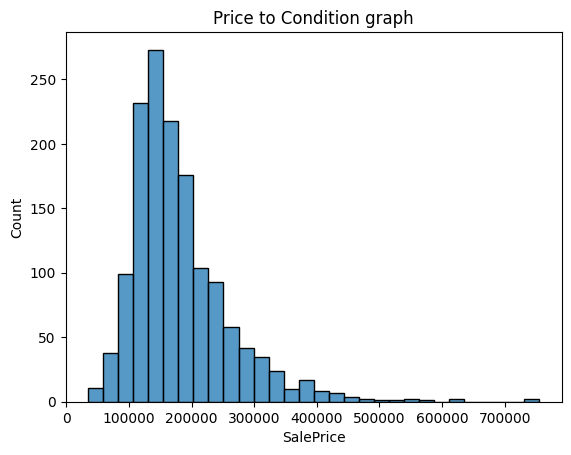

In [224]:
sns.histplot(data = df, x= 'SalePrice', bins = 30)
plt.title('Price to Condition graph')
plt.show()

In [225]:
df['YearBuilt'] = 2010 - df['YearBuilt']

In [226]:
encoder = OneHotEncoder(sparse_output = False).set_output(transform = 'pandas')
one_hot_encoded = encoder.fit_transform(df[['MSSubClass','BldgType','MSZoning','Exterior1st','LotConfig']])
df_encoded = pd.concat([df.drop(['MSSubClass','BldgType','MSZoning','Exterior1st','LotConfig'],axis = 1),one_hot_encoded],axis = 1)
df_encoded

,Id,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,SalePrice,MSSubClass_20,MSSubClass_30,...,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing,Exterior1st_nan,LotConfig_Corner,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside
0,0,8450,5,7,2003,0.0,856.0,208500.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,1,9600,8,34,1976,0.0,1262.0,181500.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,2,11250,5,9,2002,0.0,920.0,223500.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,3,9550,5,95,1970,0.0,756.0,140000.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,4,14260,5,10,2000,0.0,1145.0,250000.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,2914,1936,7,40,1970,0.0,546.0,NaN,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2915,2915,1894,5,40,1970,0.0,546.0,NaN,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2916,2916,20000,7,50,1996,0.0,1224.0,NaN,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2917,2917,10441,5,18,1992,0.0,912.0,NaN,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [227]:
mean_sale_price = df_encoded['SalePrice'].mean()
std_sale_price = df_encoded['SalePrice'].std()
upper_limit = mean_sale_price + (3 * std_sale_price)
lower_limit = mean_sale_price - (3* std_sale_price)
df_filtered = df_encoded[((df_encoded['SalePrice'] > lower_limit) & (df_encoded['SalePrice'] < upper_limit))]
len(df_filtered)

1438

In [228]:
X = df_filtered.drop(['SalePrice','Id'],axis = 1)
y = df_filtered['SalePrice']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)  
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)
len(X_train.columns)

54

Removed Outlier Values

<Axes: xlabel='SalePrice', ylabel='Count'>

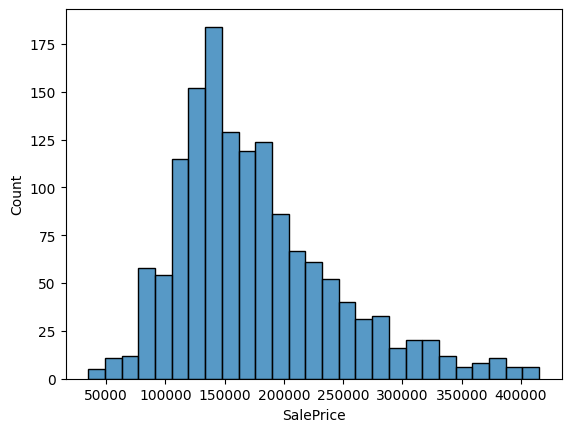

In [229]:
sns.histplot(data = df_filtered,x = 'SalePrice')

R2 Score = 74%
Mean Absolute error = 22977
Difference between MAE and mean = 13%


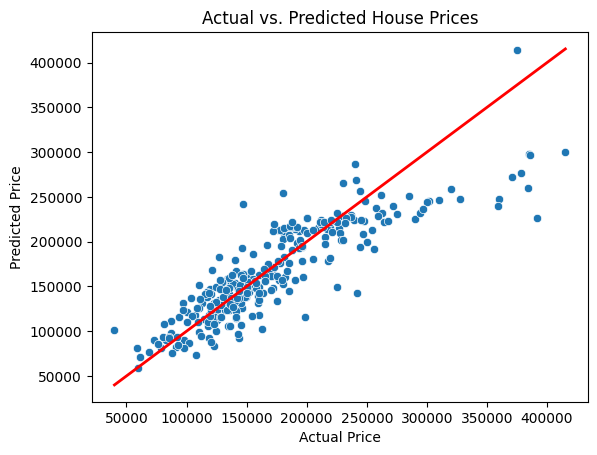

In [230]:
model = LinearRegression()
model.fit(X_train,y_train_log)
predictions = model.predict(X_test)
predictions_norm = np.expm1(predictions)
r2 = r2_score(y_test,predictions_norm)
meanabserr = mean_absolute_error(y_test,predictions_norm)
mean = df_filtered['SalePrice'].mean()
diff = ((mean - (mean - meanabserr)) / mean) * 100
print(f"R2 Score = {int(r2 * 100)}%")
print(f"Mean Absolute error = {int(meanabserr)}")
print(f"Difference between MAE and mean = {int(diff)}%")

#------------------------Data Visualization-------------------------#
sns.scatterplot(x=y_test, y=predictions_norm)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs. Predicted House Prices')
plt.show()

In [231]:
corrm = df.corr(numeric_only=True)   
corrm

,Id,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,SalePrice
Id,1.000000,0.008931,-0.040746,-0.002839,0.016581,-0.050438,0.018251,-0.024924,-0.021917
MSSubClass,0.008931,1.000000,-0.201730,-0.065625,-0.034409,0.043315,-0.072530,-0.219965,-0.084284
LotArea,-0.040746,-0.201730,1.000000,-0.035617,-0.024128,0.021612,0.084059,0.254138,0.263843
OverallCond,-0.002839,-0.065625,-0.035617,1.000000,0.368477,0.047654,0.041501,-0.174002,-0.077856
YearBuilt,0.016581,-0.034409,-0.024128,0.368477,1.000000,-0.612235,0.027595,-0.408515,-0.522897
YearRemodAdd,-0.050438,0.043315,0.021612,0.047654,-0.612235,1.000000,-0.062153,0.298107,0.507101
BsmtFinSF2,0.018251,-0.072530,0.084059,0.041501,0.027595,-0.062153,1.000000,0.089410,-0.011378
TotalBsmtSF,-0.024924,-0.219965,0.254138,-0.174002,-0.408515,0.298107,0.089410,1.000000,0.613581
SalePrice,-0.021917,-0.084284,0.263843,-0.077856,-0.522897,0.507101,-0.011378,0.613581,1.000000
